In [9]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans

In [11]:
df = pd.read_csv("bank_data.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [27]:
DATA_PATH = "bank_data.csv"   
TARGET_COL = "y"              
ID_COLS = ["id", "customer_id", "Client ID", "client_id"]

RANDOM_STATE = 42

In [29]:
df = pd.read_csv("bank_data.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [31]:
# Standardize column names (optional but helpful)
df.columns = [c.strip().lower() for c in df.columns]

# Treat common placeholders as missing (adjust if needed)
df = df.replace({"unknown": np.nan, "UNK": np.nan, "": np.nan})

# Quick missing overview
missing = df.isna().mean().sort_values(ascending=False)
display(missing[missing > 0])


poutcome     0.745924
contact      0.210177
education    0.044526
job          0.006271
dtype: float64

In [33]:
target_col = "deposit" if "deposit" in df.columns else None

# Option A (recommended for segmentation): exclude deposit + duration
exclude_cols = [c for c in [target_col, "duration"] if c is not None]

# Option B: if you want to include duration, comment above and do:
# exclude_cols = [c for c in [target_col] if c is not None]

feature_cols = [c for c in df.columns if c not in exclude_cols]
print("Using features:", feature_cols)
print("Excluded:", exclude_cols)

X = df[feature_cols].copy()

# Save target separately (optional)
y = df[target_col].copy() if target_col else None


Using features: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']
Excluded: ['deposit', 'duration']


In [35]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

def cap_outliers_iqr_or_quantile(df_in, cols, low=0.01, high=0.99):
    df_out = df_in.copy()
    for c in cols:
        lo = df_out[c].quantile(low)
        hi = df_out[c].quantile(high)
        df_out[c] = df_out[c].clip(lo, hi)
    return df_out

X = cap_outliers_iqr_or_quantile(X, numeric_cols, low=0.01, high=0.99)


Numeric: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [37]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

# Fit + transform once (ready for clustering)
X_ready = preprocessor.fit_transform(X)

print("X_ready shape:", X_ready.shape)


X_ready shape: (11162, 46)


In [39]:
k = 5  
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
clusters = kmeans.fit_predict(X_ready)

df["cluster"] = clusters
df[["cluster"]].value_counts().head(10)


cluster
1          3755
0          3737
3          2193
4           741
2           736
Name: count, dtype: int64

In [41]:
if target_col:
    display(pd.crosstab(df["cluster"], df[target_col], normalize="index"))


deposit,no,yes
cluster,,
0,0.546160,0.453840
1,0.590679,0.409321
2,0.432065,0.567935
3,0.344277,0.655723
4,0.730094,0.269906


In [43]:
cluster_summary = (
    pd.crosstab(df["cluster"], df["deposit"], normalize="index")
    .sort_values(by="yes", ascending=False)
)

cluster_summary


deposit,no,yes
cluster,,
3,0.344277,0.655723
2,0.432065,0.567935
0,0.546160,0.453840
1,0.590679,0.409321
4,0.730094,0.269906


In [45]:
# Select important columns for interpretation
profile_cols = [
    "age",
    "balance",
    "campaign",
    "pdays",
    "previous"
]

# Mean values per cluster (numeric)
cluster_profile_numeric = (
    df.groupby("cluster")[profile_cols]
    .mean()
    .round(2)
)

cluster_profile_numeric


,age,balance,campaign,pdays,previous
cluster,,,,,
0,41.66,858.37,1.93,4.50,0.09
1,39.49,870.99,2.02,4.57,0.08
2,46.36,9947.06,2.20,41.65,0.63
3,41.80,1179.40,1.93,231.30,3.72
4,41.10,912.02,9.91,1.47,0.05


In [47]:
# Percentage of yes/no for key categorical variables
def percent_yes(col):
    return pd.crosstab(df["cluster"], df[col], normalize="index").round(2)

percent_yes("housing")


housing,no,yes
cluster,,
0,0.54,0.46
1,0.50,0.50
2,0.64,0.36
3,0.50,0.50
4,0.54,0.46


In [51]:
percent_yes("loan")

loan,no,yes
cluster,,
0,0.87,0.13
1,0.85,0.15
2,0.95,0.05
3,0.89,0.11
4,0.83,0.17


In [53]:
percent_yes("job")


job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed
cluster,,,,,,,,,,,
0,0.11,0.20,0.03,0.03,0.21,0.08,0.03,0.08,0.03,0.16,0.04
1,0.12,0.18,0.03,0.02,0.23,0.05,0.04,0.09,0.03,0.18,0.03
2,0.07,0.12,0.03,0.02,0.31,0.14,0.04,0.04,0.03,0.17,0.03
3,0.15,0.14,0.02,0.02,0.24,0.09,0.03,0.08,0.05,0.15,0.03
4,0.12,0.17,0.04,0.03,0.25,0.04,0.04,0.10,0.02,0.18,0.02


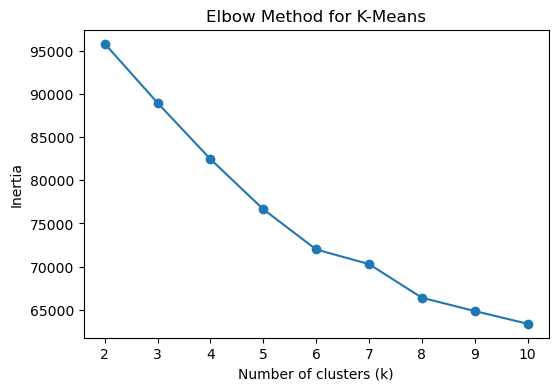

In [55]:
# ELBOW METHOD

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    km.fit(X_ready)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()


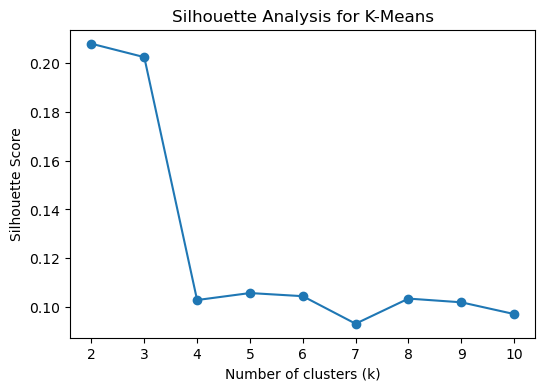

In [57]:
#SILHOUETTE SCORE

from sklearn.metrics import silhouette_score

sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    labels = km.fit_predict(X_ready)
    sil = silhouette_score(X_ready, labels)
    sil_scores.append(sil)

plt.figure(figsize=(6,4))
plt.plot(k_range, sil_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for K-Means")
plt.show()


In [75]:
# Table 4.1: Cluster Size Distribution
table_4_1 = df["cluster"].value_counts().sort_index()
table_4_1


cluster
0    3737
1    3755
2     736
3    2193
4     741
Name: count, dtype: int64

In [77]:
df["cluster"].value_counts(normalize=True).sort_index().round(3)


cluster
0    0.335
1    0.336
2    0.066
3    0.196
4    0.066
Name: proportion, dtype: float64

In [79]:
# Table 4.2: Numeric Cluster Profile
numeric_cols = ["age", "balance", "campaign", "pdays", "previous"]

table_4_2 = (
    df.groupby("cluster")[numeric_cols]
      .mean()
      .round(2)
)

table_4_2


,age,balance,campaign,pdays,previous
cluster,,,,,
0,41.66,858.37,1.93,4.50,0.09
1,39.49,870.99,2.02,4.57,0.08
2,46.36,9947.06,2.20,41.65,0.63
3,41.80,1179.40,1.93,231.30,3.72
4,41.10,912.02,9.91,1.47,0.05


In [81]:
# Table 4.3: Housing Loan Distribution
table_4_3 = pd.crosstab(
    df["cluster"],
    df["housing"],
    normalize="index"
).round(3)

table_4_3


housing,no,yes
cluster,,
0,0.542,0.458
1,0.502,0.498
2,0.641,0.359
3,0.500,0.500
4,0.541,0.459


In [83]:
# Table 4.4: Personal Loan Distribution
table_4_4 = pd.crosstab(
    df["cluster"],
    df["loan"],
    normalize="index"
).round(3)

table_4_4


loan,no,yes
cluster,,
0,0.870,0.130
1,0.847,0.153
2,0.948,0.052
3,0.893,0.107
4,0.827,0.173


In [85]:
# Table 4.5: Job Category Distribution
table_4_5 = pd.crosstab(
    df["cluster"],
    df["job"],
    normalize="index"
).round(3)

table_4_5


job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed
cluster,,,,,,,,,,,
0,0.115,0.198,0.031,0.031,0.212,0.076,0.034,0.082,0.031,0.155,0.036
1,0.120,0.183,0.032,0.022,0.227,0.047,0.039,0.093,0.028,0.178,0.032
2,0.073,0.123,0.030,0.022,0.307,0.144,0.041,0.040,0.026,0.167,0.026
3,0.148,0.142,0.020,0.017,0.242,0.085,0.034,0.079,0.050,0.150,0.032
4,0.116,0.172,0.035,0.033,0.248,0.041,0.040,0.098,0.018,0.179,0.020


In [87]:
table_4_5 = table_4_5[table_4_5.mean().sort_values(ascending=False).index]
table_4_5


job,management,technician,blue-collar,admin.,retired,services,self-employed,student,entrepreneur,unemployed,housemaid
cluster,,,,,,,,,,,
0,0.212,0.155,0.198,0.115,0.076,0.082,0.034,0.031,0.031,0.036,0.031
1,0.227,0.178,0.183,0.120,0.047,0.093,0.039,0.028,0.032,0.032,0.022
2,0.307,0.167,0.123,0.073,0.144,0.040,0.041,0.026,0.030,0.026,0.022
3,0.242,0.150,0.142,0.148,0.085,0.079,0.034,0.050,0.020,0.032,0.017
4,0.248,0.179,0.172,0.116,0.041,0.098,0.040,0.018,0.035,0.020,0.033


In [89]:
# Table 4.6: Deposit Subscription Rate
table_4_6 = pd.crosstab(
    df["cluster"],
    df["deposit"],
    normalize="index"
).round(3)

table_4_6


deposit,no,yes
cluster,,
0,0.546,0.454
1,0.591,0.409
2,0.432,0.568
3,0.344,0.656
4,0.730,0.270


In [91]:
table_4_6.sort_values(by="yes", ascending=False)


deposit,no,yes
cluster,,
3,0.344,0.656
2,0.432,0.568
0,0.546,0.454
1,0.591,0.409
4,0.730,0.270


In [93]:
# Each row should sum to 1
table_4_3.sum(axis=1)
table_4_4.sum(axis=1)
table_4_6.sum(axis=1)


cluster
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float64

# DBSCAN

In [101]:
from sklearn.decomposition import PCA


pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_ready)

print("Original shape:", X_ready.shape)
print("After PCA shape:", X_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum().round(3))


Original shape: (11162, 46)
After PCA shape: (11162, 23)
Explained variance: 0.951


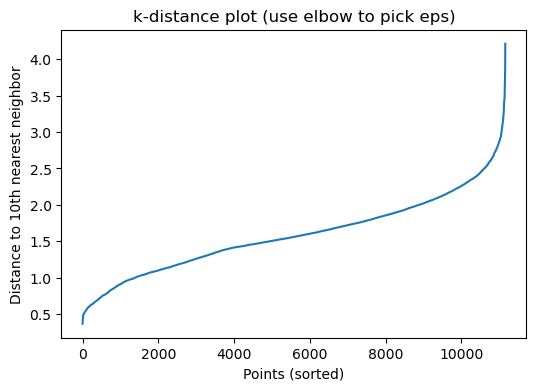

In [103]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

min_samples = 10 

nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_pca)
distances, indices = nn.kneighbors(X_pca)

# distance to the kth nearest neighbor
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6,4))
plt.plot(k_distances)
plt.xlabel("Points (sorted)")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.title("k-distance plot (use elbow to pick eps)")
plt.show()


In [105]:
from sklearn.cluster import DBSCAN
import numpy as np

eps = 0.9  
dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)

db_labels = dbscan.fit_predict(X_pca)

# DBSCAN uses -1 for noise
df["cluster_dbscan"] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_pct = (db_labels == -1).mean() * 100

print("DBSCAN clusters found:", n_clusters)
print("Noise points (-1):", f"{noise_pct:.2f}%")

df["cluster_dbscan"].value_counts().head(10)


DBSCAN clusters found: 48
Noise points (-1): 85.30%


cluster_dbscan
-1     9521
 2      169
 5      107
 3       98
 17      92
 7       74
 6       73
 20      70
 18      70
 8       61
Name: count, dtype: int64

In [107]:
from sklearn.metrics import silhouette_score

mask = df["cluster_dbscan"] != -1
X_eval = X_pca[mask]
labels_eval = df.loc[mask, "cluster_dbscan"]

if len(set(labels_eval)) > 1:
    sil = silhouette_score(X_eval, labels_eval)
    print("Silhouette (excluding noise):", round(sil, 3))
else:
    print("Not enough clusters to compute silhouette (excluding noise).")


Silhouette (excluding noise): 0.241


In [109]:
table_db_1 = df["cluster_dbscan"].value_counts().sort_index()
table_db_1


cluster_dbscan
-1     9521
 0       28
 1       50
 2      169
 3       98
 4       59
 5      107
 6       73
 7       74
 8       61
 9       57
 10      13
 11      16
 12      17
 13      32
 14      12
 15      14
 16      36
 17      92
 18      70
 19      22
 20      70
 21      24
 22      36
 23      10
 24      10
 25      42
 26      23
 27      55
 28      17
 29      24
 30      17
 31      13
 32      10
 33      33
 34      13
 35      20
 36      10
 37      11
 38       9
 39      14
 40      10
 41      11
 42       8
 43      10
 44      10
 45      10
 46      10
 47      11
Name: count, dtype: int64

In [111]:
profile_cols = ["age", "balance", "campaign", "pdays", "previous"]

table_db_2 = (
    df[df["cluster_dbscan"] != -1]
      .groupby("cluster_dbscan")[profile_cols]
      .mean()
      .round(2)
)
table_db_2


,age,balance,campaign,pdays,previous
cluster_dbscan,,,,,
0,40.18,471.00,1.57,-1.0,0.0
1,32.44,512.52,1.54,-1.0,0.0
2,38.38,573.34,1.87,-1.0,0.0
3,39.31,307.33,1.51,-1.0,0.0
4,38.76,496.83,1.58,-1.0,0.0
5,40.04,462.93,1.87,-1.0,0.0
6,30.59,302.34,1.66,-1.0,0.0
7,31.64,483.30,1.64,-1.0,0.0
8,33.49,592.70,1.66,-1.0,0.0


In [113]:
table_db_3 = pd.crosstab(
    df[df["cluster_dbscan"] != -1]["cluster_dbscan"],
    df[df["cluster_dbscan"] != -1]["housing"],
    normalize="index"
).round(3)
table_db_3


housing,no,yes
cluster_dbscan,,
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
5,0.0,1.0
6,0.0,1.0
7,0.0,1.0
8,0.0,1.0


In [115]:
table_db_4 = pd.crosstab(
    df[df["cluster_dbscan"] != -1]["cluster_dbscan"],
    df[df["cluster_dbscan"] != -1]["loan"],
    normalize="index"
).round(3)
table_db_4


loan,no,yes
cluster_dbscan,,
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
5,1.0,0.0
6,1.0,0.0
7,1.0,0.0
8,1.0,0.0


In [117]:
table_db_5 = pd.crosstab(
    df[df["cluster_dbscan"] != -1]["cluster_dbscan"],
    df[df["cluster_dbscan"] != -1]["job"],
    normalize="index"
).round(3)


table_db_5 = table_db_5[table_db_5.mean().sort_values(ascending=False).index]
table_db_5


job,management,blue-collar,technician,admin.,services,student,retired,unemployed,self-employed,entrepreneur,housemaid
cluster_dbscan,,,,,,,,,,,
0,0.0,0.0,1.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.0,0.0,0.0,1.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.0,1.0,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.0,0.0,0.0,0.0,0.663,0.000,0.071,0.061,0.092,0.092,0.020
4,0.0,0.0,0.0,1.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,0.0,1.0,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
6,0.0,1.0,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7,0.0,0.0,0.0,0.0,0.716,0.135,0.000,0.054,0.068,0.014,0.014
8,0.0,0.0,1.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [119]:
table_db_6 = pd.crosstab(
    df[df["cluster_dbscan"] != -1]["cluster_dbscan"],
    df[df["cluster_dbscan"] != -1]["deposit"],
    normalize="index"
).round(3)
table_db_6


deposit,no,yes
cluster_dbscan,,
0,0.786,0.214
1,0.740,0.260
2,0.704,0.296
3,0.837,0.163
4,0.780,0.220
5,0.822,0.178
6,0.671,0.329
7,0.581,0.419
8,0.787,0.213


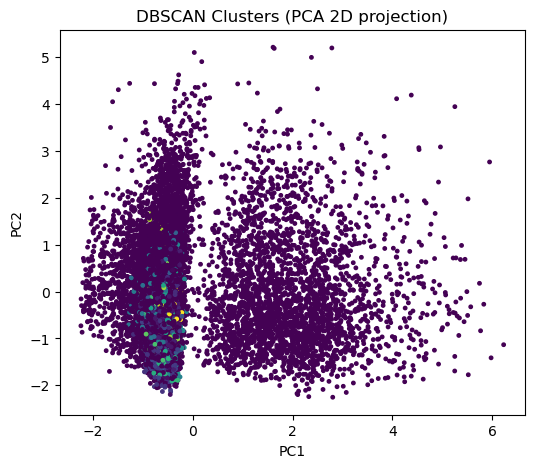

In [121]:
import matplotlib.pyplot as plt

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2.fit_transform(X_ready)

labels = df["cluster_dbscan"].values

plt.figure(figsize=(6,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, s=6)
plt.title("DBSCAN Clusters (PCA 2D projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [128]:
df["cluster_dbscan"].value_counts()


cluster_dbscan
-1     9521
 2      169
 5      107
 3       98
 17      92
 7       74
 6       73
 20      70
 18      70
 8       61
 4       59
 9       57
 27      55
 1       50
 25      42
 22      36
 16      36
 33      33
 13      32
 0       28
 29      24
 21      24
 26      23
 19      22
 35      20
 28      17
 12      17
 30      17
 11      16
 39      14
 15      14
 10      13
 31      13
 34      13
 14      12
 37      11
 41      11
 47      11
 40      10
 32      10
 43      10
 44      10
 46      10
 23      10
 24      10
 36      10
 45      10
 38       9
 42       8
Name: count, dtype: int64

In [130]:
pd.crosstab(
    df[df["cluster_dbscan"] != -1]["cluster_dbscan"],
    df[df["cluster_dbscan"] != -1]["deposit"],
    normalize="index"
)


deposit,no,yes
cluster_dbscan,,
0,0.785714,0.214286
1,0.740000,0.260000
2,0.704142,0.295858
3,0.836735,0.163265
4,0.779661,0.220339
5,0.822430,0.177570
6,0.671233,0.328767
7,0.581081,0.418919
8,0.786885,0.213115


In [132]:
import numpy as np
import pandas as pd

labels = df["cluster_dbscan"]

total_n = len(labels)
noise_n = (labels == -1).sum()
noise_pct = noise_n / total_n

# cluster sizes excluding noise
cluster_sizes = labels[labels != -1].value_counts().sort_values(ascending=False)

summary_db1 = pd.DataFrame({
    "metric": [
        "Total records",
        "Clusters found (excluding noise)",
        "Noise points (label = -1)",
        "Noise percentage",
        "Largest cluster size",
        "Median cluster size",
        "Smallest cluster size",
    ],
    "value": [
        total_n,
        cluster_sizes.shape[0],
        noise_n,
        round(noise_pct * 100, 2),
        int(cluster_sizes.max()) if len(cluster_sizes) else 0,
        float(cluster_sizes.median()) if len(cluster_sizes) else 0,
        int(cluster_sizes.min()) if len(cluster_sizes) else 0,
    ]
})

summary_db1


,metric,value
0,Total records,11162.0
1,Clusters found (excluding noise),48.0
2,Noise points (label = -1),9521.0
3,Noise percentage,85.3
4,Largest cluster size,169.0
5,Median cluster size,18.5
6,Smallest cluster size,8.0


In [134]:
topN = 10

table_db2 = (
    cluster_sizes.head(topN)
    .rename("size")
    .to_frame()
)

table_db2["pct_of_data"] = (table_db2["size"] / total_n * 100).round(2)
table_db2.index.name = "cluster_id"

table_db2


,size,pct_of_data
cluster_id,,
2,169,1.51
5,107,0.96
3,98,0.88
17,92,0.82
7,74,0.66
6,73,0.65
18,70,0.63
20,70,0.63
8,61,0.55


In [136]:
min_cluster_size = 50   
topN = 10

df_non_noise = df[df["cluster_dbscan"] != -1].copy()

# size per cluster
sizes = df_non_noise["cluster_dbscan"].value_counts()

# compute deposit_yes_rate per cluster
# (assumes deposit values are "yes"/"no")
yes_rate = (
    df_non_noise.assign(deposit_yes = (df_non_noise["deposit"] == "yes").astype(int))
    .groupby("cluster_dbscan")["deposit_yes"]
    .mean()
)

table_db3 = pd.DataFrame({
    "size": sizes,
    "deposit_yes_rate": (yes_rate * 100).round(2)
})

# filter small clusters + rank
table_db3 = (
    table_db3[table_db3["size"] >= min_cluster_size]
    .sort_values(by="deposit_yes_rate", ascending=False)
    .head(topN)
)

table_db3.index.name = "cluster_id"
table_db3


,size,deposit_yes_rate
cluster_id,,
20,70,68.57
7,74,41.89
17,92,34.78
6,73,32.88
18,70,31.43
27,55,30.91
2,169,29.59
9,57,26.32
1,50,26.00


In [138]:
# --- DBSCAN compact thesis tables ---
import numpy as np
import pandas as pd

# 1) Summary table
labels = df["cluster_dbscan"].values
total_n = len(labels)

noise_n = int((labels == -1).sum())
clusters_found = int(len(set(labels)) - (1 if -1 in labels else 0))

# cluster sizes excluding noise
cluster_sizes = df.loc[df["cluster_dbscan"] != -1, "cluster_dbscan"].value_counts()
largest = int(cluster_sizes.max()) if len(cluster_sizes) else 0
median = float(cluster_sizes.median()) if len(cluster_sizes) else 0
smallest = int(cluster_sizes.min()) if len(cluster_sizes) else 0

table_db_1 = pd.DataFrame({
    "metric": [
        "Total records",
        "Clusters found (excluding noise)",
        "Noise points (label = -1)",
        "Noise percentage",
        "Largest cluster size",
        "Median cluster size",
        "Smallest cluster size"
    ],
    "value": [
        total_n,
        clusters_found,
        noise_n,
        round(noise_n / total_n * 100, 1),
        largest,
        round(median, 1),
        smallest
    ]
})
table_db_1


,metric,value
0,Total records,11162.0
1,Clusters found (excluding noise),48.0
2,Noise points (label = -1),9521.0
3,Noise percentage,85.3
4,Largest cluster size,169.0
5,Median cluster size,18.5
6,Smallest cluster size,8.0


In [140]:
# 2) Top-N largest clusters
topN = 10
table_db_2 = (
    cluster_sizes.head(topN)
    .rename("size")
    .to_frame()
)
table_db_2["pct_of_data"] = (table_db_2["size"] / total_n * 100).round(2)
table_db_2.index.name = "cluster_id"
table_db_2


,size,pct_of_data
cluster_id,,
2,169,1.51
5,107,0.96
3,98,0.88
17,92,0.82
7,74,0.66
6,73,0.65
18,70,0.63
20,70,0.63
8,61,0.55


In [142]:
# 3) Top-N clusters by deposit yes-rate (exclude noise + filter small clusters)
df_non_noise = df[df["cluster_dbscan"] != -1].copy()

sizes = df_non_noise["cluster_dbscan"].value_counts()

yes_rate = (
    df_non_noise.assign(deposit_yes=(df_non_noise["deposit"] == "yes").astype(int))
    .groupby("cluster_dbscan")["deposit_yes"]
    .mean()
)

min_cluster_size = 50   
topN = 10

table_db_3 = pd.DataFrame({
    "size": sizes,
    "deposit_yes_rate": (yes_rate * 100).round(2)
})

table_db_3 = (
    table_db_3[table_db_3["size"] >= min_cluster_size]
    .sort_values(by="deposit_yes_rate", ascending=False)
    .head(topN)
)

table_db_3.index.name = "cluster_id"
table_db_3


,size,deposit_yes_rate
cluster_id,,
20,70,68.57
7,74,41.89
17,92,34.78
6,73,32.88
18,70,31.43
27,55,30.91
2,169,29.59
9,57,26.32
1,50,26.00


# GMM

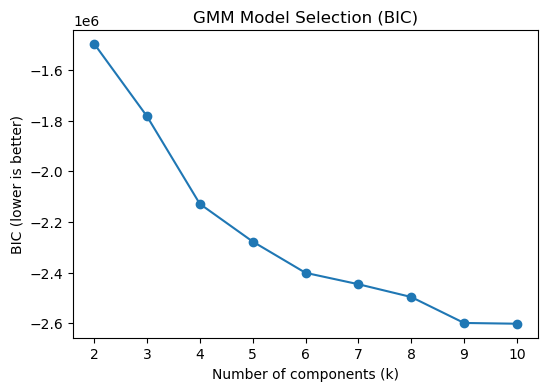

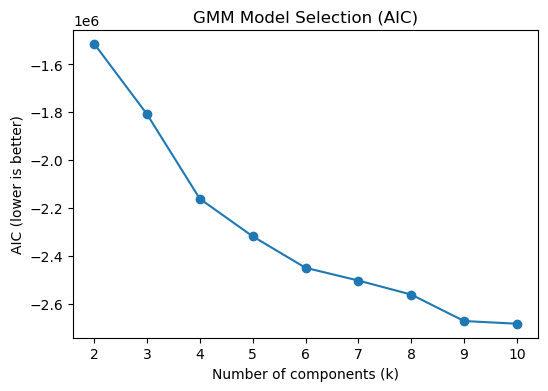

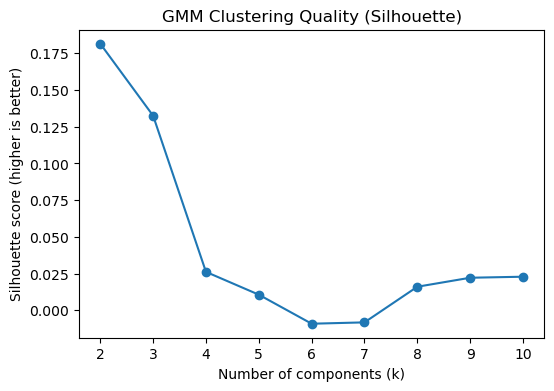

Best k by BIC: 10


In [145]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

k_range = range(2, 11)

bics, aics, sils = [], [], []

for k in k_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",   
        random_state=RANDOM_STATE,
        reg_covar=1e-6            # helps numerical stability
    )
    labels = gmm.fit_predict(X_ready)

    bics.append(gmm.bic(X_ready))
    aics.append(gmm.aic(X_ready))

    # silhouette needs at least 2 clusters and not all same label
    sils.append(silhouette_score(X_ready, labels))

# Plot BIC/AIC (lower is better)
plt.figure(figsize=(6,4))
plt.plot(list(k_range), bics, marker="o")
plt.xlabel("Number of components (k)")
plt.ylabel("BIC (lower is better)")
plt.title("GMM Model Selection (BIC)")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(list(k_range), aics, marker="o")
plt.xlabel("Number of components (k)")
plt.ylabel("AIC (lower is better)")
plt.title("GMM Model Selection (AIC)")
plt.show()

# Plot silhouette (higher is better)
plt.figure(figsize=(6,4))
plt.plot(list(k_range), sils, marker="o")
plt.xlabel("Number of components (k)")
plt.ylabel("Silhouette score (higher is better)")
plt.title("GMM Clustering Quality (Silhouette)")
plt.show()

best_k_bic = list(k_range)[int(np.argmin(bics))]
print("Best k by BIC:", best_k_bic)


In [157]:
best_k = best_k_bic

gmm_final = GaussianMixture(
    n_components=best_k,
    covariance_type="full",
    random_state=RANDOM_STATE,
    reg_covar=1e-6
)

gmm_labels = gmm_final.fit_predict(X_ready)

df["cluster_gmm"] = gmm_labels
df["cluster_gmm"].value_counts().sort_index()


cluster_gmm
0     603
1     762
2    3176
3     209
4    1283
5     801
6     190
7     541
8    2786
9     811
Name: count, dtype: int64

In [159]:
table_g1 = df["cluster_gmm"].value_counts().sort_index().to_frame("size")
table_g1["pct_of_data"] = (table_g1["size"] / len(df) * 100).round(2)
table_g1


,size,pct_of_data
cluster_gmm,,
0,603,5.40
1,762,6.83
2,3176,28.45
3,209,1.87
4,1283,11.49
5,801,7.18
6,190,1.70
7,541,4.85
8,2786,24.96


In [161]:
table_g2 = pd.crosstab(df["cluster_gmm"], df["deposit"], normalize="index").round(3)
table_g2


deposit,no,yes
cluster_gmm,,
0,0.433,0.567
1,0.513,0.487
2,0.693,0.307
3,0.435,0.565
4,0.228,0.772
5,0.438,0.562
6,0.247,0.753
7,0.259,0.741
8,0.649,0.351


In [163]:
profile_cols = ["age", "balance", "campaign", "pdays", "previous"]

table_g3 = (
    df.groupby("cluster_gmm")[profile_cols]
      .mean()
      .round(2)
)
table_g3


,age,balance,campaign,pdays,previous
cluster_gmm,,,,,
0,56.19,1906.95,2.40,-1.00,0.00
1,39.86,1133.96,2.09,243.13,3.33
2,38.17,1155.96,2.60,-1.00,0.00
3,38.95,1455.20,2.11,162.27,3.40
4,38.23,1732.00,1.95,114.90,1.98
5,47.74,2040.89,1.69,-1.00,0.00
6,52.21,1859.47,1.84,185.77,2.61
7,51.52,2716.82,1.77,170.93,3.37
8,41.56,1404.95,3.43,-1.00,0.00


In [165]:
probs = gmm_final.predict_proba(X_ready)
df["gmm_max_prob"] = probs.max(axis=1).round(3)

df["gmm_max_prob"].describe()


count    11162.000000
mean         0.998236
std          0.025416
min          0.506000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: gmm_max_prob, dtype: float64